# Chapter: Image Features
## Feature Engineering & MLOps

**Teaching a model to "see" is really just teaching it to work with numbers arranged in a
grid.** This chapter walks from a single tiny image, represented as plain numbers, all the way
to how modern CNNs and transfer learning let models learn their own features automatically.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain what an image is, from a machine learning perspective (a matrix of numbers)
- Explain why raw pixels alone are often a poor feature representation
- Compute and interpret HOG (Histogram of Oriented Gradients) descriptors
- Explain SIFT conceptually, without the underlying math
- Explain why CNNs learn features automatically, and how early vs. deep layers differ
- Explain and demonstrate transfer learning — reusing features learned on one task for another
- Explain the difference between flattening and pooling
- Compare raw pixels, HOG, SIFT, and CNN embeddings as feature representations

## Real-World Problem

A bank processes thousands of handwritten cheques and forms every day. Someone has to manually
read the handwritten digits (amounts, account numbers) — slow, expensive, and error-prone at
scale. The bank wants a model that reads a small image of a handwritten digit and predicts
which digit (0-9) it is.

- **Raw data available:** small grayscale images of handwritten digits.
- **Target:** which digit (0-9) the image shows.
- **What features might we create?** This entire chapter is about answering that question —
  from the simplest possible approach (raw pixel values) to the most powerful (CNN-learned
  features and transfer learning).
- **Why the business cares:** faster, cheaper, more accurate digit recognition means faster
  cheque processing and fewer costly manual-entry errors.

## Why Do We Need This Concept?

**Why isn't an image just... directly usable?** An image, at its core, IS already numbers — a
grid of pixel brightness values. So what's the problem?

The real issue is that a **raw pixel grid is extremely sensitive to exactly where things are**.
Shift a handwritten "7" two pixels to the left, and every single pixel value changes — even
though it's obviously still a "7" to a human eye. A model trained on raw pixel values alone has
to somehow learn that thousands of totally different-looking pixel patterns all mean the same
digit — an enormously harder job than it needs to be. Good image FEATURES exist specifically to
capture the shape/structure of what's in an image in a way that's more robust to exactly this
kind of shift, without losing the information that actually matters.

**What happens if we skip this?** A model fed only raw, unprocessed pixels often needs vastly
more training data and vastly more capacity to learn what a slightly-shifted, slightly-rotated,
slightly-differently-drawn digit has in common with another — features (hand-crafted or
learned) exist to make that job dramatically easier.

## Concept Intuition

```
IMAGE (from an ML perspective)
    |
    v
a 2D grid of numbers, one number per pixel
(0 = black, higher = brighter, for grayscale)

  [ 0   0  12 200 255 200  12   0 ]
  [ 0  40 180 255 255 255 180  40 ]
  [ ...                          ]

    |
    v
FEATURE EXTRACTION  (this whole chapter)
    |
    +-- Raw pixels        -- every pixel value, flattened into one long list
    +-- HOG               -- "which direction do edges point, in each small patch?"
    +-- SIFT               -- "find distinctive corner/blob points, describe them robustly"
    +-- CNN embeddings     -- the network LEARNS what patterns matter, automatically
```

## Tiny Manual Example — pixel representation

Let's look at a TINY 5×5 grayscale image, by hand, before writing any code.

The image AS A MATRIX OF NUMBERS -- this is literally all a model ever sees:
[[ 10  10 200 200 200]
 [ 10  10 200 200 200]
 [ 10  10 200 200 200]
 [ 10  10 200 200 200]
 [ 10  10 200 200 200]]


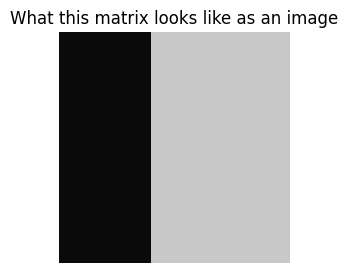

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A tiny 5x5 grayscale image (values 0=black to 255=white) -- looks like a simple vertical edge
tiny_image = np.array([
    [10,  10,  200, 200, 200],
    [10,  10,  200, 200, 200],
    [10,  10,  200, 200, 200],
    [10,  10,  200, 200, 200],
    [10,  10,  200, 200, 200],
])

print("The image AS A MATRIX OF NUMBERS -- this is literally all a model ever sees:")
print(tiny_image)

plt.figure(figsize=(3, 3))
plt.imshow(tiny_image, cmap="gray", vmin=0, vmax=255)
plt.title("What this matrix looks like as an image")
plt.axis("off")
plt.show()

**What to notice:** the LEFT two columns are dark (value 10), the RIGHT three columns are
bright (value 200) — visually, this is a clean vertical edge. But to a model, it's just 25
individual numbers with no built-in sense that "column 2 and column 3 being very different
matters" or that "this pattern would look identical if shifted one column to the right." That
missing sense of STRUCTURE is exactly the gap every technique in this chapter tries to fill.

## The dataset

We use scikit-learn's built-in **digits dataset**: 1,797 tiny (8×8 pixel) grayscale images of
handwritten digits 0-9. It's built into `sklearn` — no download needed, and small enough to run
entirely on a CPU, in seconds.

Images shape: (1797, 8, 8)
Labels shape: (1797,)


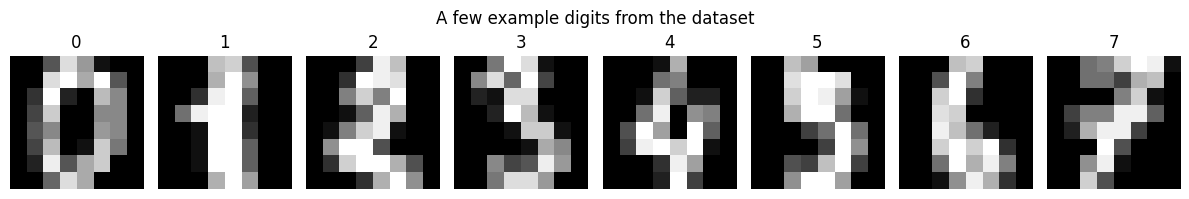

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
print("Images shape:", digits.images.shape)   # (1797, 8, 8)
print("Labels shape:", digits.target.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.suptitle("A few example digits from the dataset")
plt.tight_layout()
plt.show()

## Raw pixels as features — the simplest possible approach

The most basic thing we can do: flatten each 8×8 image into a single row of 64 numbers, and
feed that straight into a model.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_raw = digits.data   # already flattened: (1797, 64)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, random_state=42, stratify=y)

model_raw = LogisticRegression(max_iter=3000).fit(X_train, y_train)
acc_raw = accuracy_score(y_test, model_raw.predict(X_test))
print(f"Accuracy using raw flattened pixels: {acc_raw:.1%}")

Accuracy using raw flattened pixels: 96.2%


**Keep this number in mind** — we'll compare every other feature representation in this
chapter back to this raw-pixel baseline.

## Explaining edges with a simple visual example

Before HOG, let's see what an "edge" looks like numerically. An edge is simply a place where
pixel brightness changes SHARPLY from one pixel to the next.

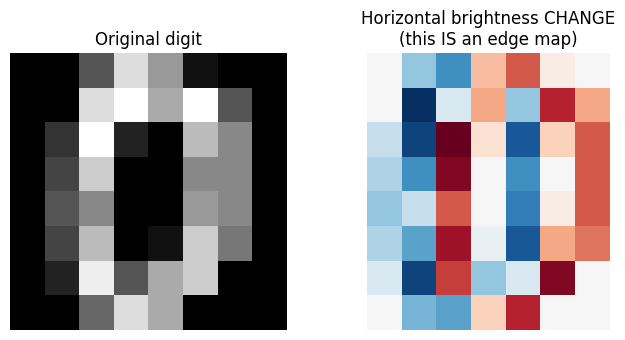

In [4]:
sample_digit = digits.images[0]

# A simple horizontal gradient: how much does brightness change from one column to the next?
horizontal_gradient = np.diff(sample_digit, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(sample_digit, cmap="gray")
axes[0].set_title("Original digit")
axes[0].axis("off")
axes[1].imshow(horizontal_gradient, cmap="RdBu")
axes[1].set_title("Horizontal brightness CHANGE\n(this IS an edge map)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**What to notice:** the gradient image is near-zero (white/pale) almost everywhere EXCEPT
where the digit's stroke creates a sharp light-to-dark or dark-to-light transition — those
transitions ARE the edges. HOG builds directly on this idea.

## HOG intuitively: "which direction do the edges point?"

**Analogy:** imagine describing a shape to a friend over the phone, without showing them the
picture — you might say "there's a diagonal line going from bottom-left to top-right here, and
a horizontal line here." That's exactly what HOG does automatically: it divides the image into
small cells, and in each cell, asks "what direction do the edges mostly point?" — then builds a
histogram (a count) of edge directions per cell.

```
Small image patch          HOG summarizes it as:
                           "mostly edges pointing diagonally (~45 degrees) in this cell"
   \  \  |
    \  \ |
     \ \ |
```

This makes HOG naturally more robust to small shifts than raw pixels — a digit shifted by one
pixel has almost the SAME edge-direction pattern, even though every individual pixel value
changed.

## Demonstrating HOG with `skimage`

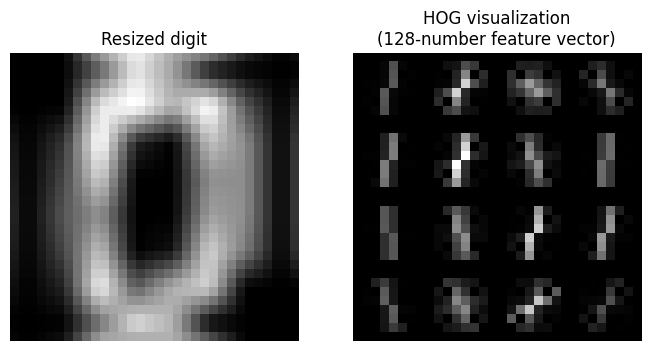

In [5]:
from skimage.feature import hog
from skimage.transform import resize

# 8x8 is tiny for a meaningful HOG demo -- resize up so cells have enough pixels to describe
sample_resized = resize(sample_digit, (32, 32))

hog_features, hog_image = hog(
    sample_resized, orientations=8, pixels_per_cell=(8, 8),
    cells_per_block=(1, 1), visualize=True,
)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(sample_resized, cmap="gray")
axes[0].set_title("Resized digit")
axes[0].axis("off")
axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title(f"HOG visualization\n({len(hog_features)}-number feature vector)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**What should you notice?** The HOG visualization highlights the DIRECTION of edges in each
cell as small line segments — you can still make out the digit's basic shape, but now encoded
as "edge directions per region" rather than raw brightness values.

In [6]:
# Build HOG features for the WHOLE dataset, and compare accuracy against raw pixels
def extract_hog_features(images):
    features = []
    for img in images:
        img_resized = resize(img, (32, 32))
        feat = hog(img_resized, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(1, 1))
        features.append(feat)
    return np.array(features)

X_hog = extract_hog_features(digits.images)
print("HOG feature matrix shape:", X_hog.shape)

X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    X_hog, y, test_size=0.25, random_state=42, stratify=y
)
model_hog = LogisticRegression(max_iter=3000).fit(X_train_hog, y_train_hog)
acc_hog = accuracy_score(y_test_hog, model_hog.predict(X_test_hog))
print(f"Accuracy using HOG features: {acc_hog:.1%}  (vs. {acc_raw:.1%} using raw pixels)")

HOG feature matrix shape: (1797, 128)
Accuracy using HOG features: 98.2%  (vs. 96.2% using raw pixels)


## SIFT — conceptual overview (no deep math)

**SIFT (Scale-Invariant Feature Transform)** takes a different approach than HOG. Instead of
describing the WHOLE image uniformly cell by cell, SIFT first finds a handful of especially
**distinctive points** in the image — corners, blobs, sharp intersections — and then describes
each of those points in a way that stays recognizable even if the image is scaled, rotated, or
lit differently.

**Analogy:** if HOG is like describing an entire face by scanning left-to-right, top-to-bottom
in a grid, SIFT is like a witness saying "the most distinctive things about this face are the
mole on the left cheek and the shape of the eyebrows" — a much smaller number of highly
specific, memorable landmarks, described in a way that's recognizable whether the photo was
taken close-up, from far away, or at an angle.

SIFT is most valuable for tasks like matching the SAME object across two different photos
(image stitching, object recognition, matching a logo at different sizes) — less commonly used
for digit classification specifically, but worth seeing in action.

SIFT found 18 distinctive keypoints
Each keypoint is described by a 128-number descriptor


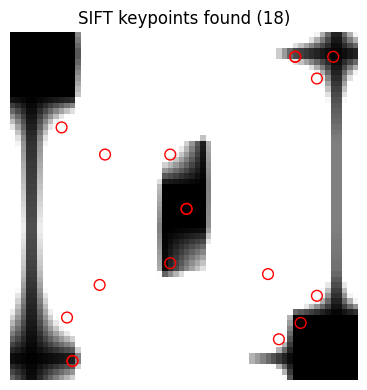

In [7]:
from skimage.feature import SIFT
from skimage.transform import resize

sample_resized_large = resize(sample_digit, (64, 64))
# clip before casting to uint8 -- upsampling interpolation can overshoot slightly
# outside [0, 1], which wraps around to near-255 noise if cast to uint8 unclipped
sample_resized_large = np.clip(sample_resized_large, 0, 1)
sample_uint8 = (sample_resized_large * 255).astype(np.uint8)

sift_detector = SIFT()
sift_detector.detect_and_extract(sample_uint8)

print(f"SIFT found {len(sift_detector.keypoints)} distinctive keypoints")
print(f"Each keypoint is described by a {sift_detector.descriptors.shape[1]}-number descriptor")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample_uint8, cmap="gray")
ax.scatter(sift_detector.keypoints[:, 1], sift_detector.keypoints[:, 0],
           facecolors="none", edgecolors="red", s=60)
ax.set_title(f"SIFT keypoints found ({len(sift_detector.keypoints)})")
ax.axis("off")
plt.tight_layout()
plt.show()

**What should you notice?** The red circles mark where SIFT found distinctive points —
typically along the curves and corners of the digit's stroke, NOT the flat blank background.
Unlike HOG (which describes EVERY cell uniformly), SIFT concentrates entirely on these few
"interesting" locations.

## Why CNNs learn features automatically

Both HOG and SIFT are **hand-crafted**: a human decided, in advance, exactly what calculation
("histogram of edge directions," "find corners and describe them") the feature extraction
would perform. That calculation never changes, no matter what data you feed it.

A **Convolutional Neural Network (CNN)** flips this around: instead of a human deciding what to
compute, the network starts with RANDOM filters and gradually adjusts them, through training,
to whatever patterns actually turn out to be useful for the specific task at hand. Nobody tells
the CNN to look for edges, corners, or curves — it discovers that these are useful building
blocks entirely on its own, purely by trying to get better at the classification task.

## Early CNN features vs. deeper CNN features

A CNN is built from stacked layers, and different depths tend to learn very different KINDS of
patterns:

```
INPUT IMAGE
    |
    v
EARLY layers   -->  learn simple, generic patterns: edges, corners, color blobs
    |               (similar in spirit to what HOG/SIFT hand-craft!)
    v
MIDDLE layers  -->  learn combinations of simple patterns: curves, textures, simple shapes
    |
    v
DEEPER layers  -->  learn complex, TASK-SPECIFIC patterns: "loop shapes" (like in 0, 6, 8, 9),
                     "a single vertical stroke" (like in 1), whole-digit-like structures
    |
    v
FINAL layer    -->  combines everything into a decision: "this is a 7"
```

This is exactly why transfer learning works (next section): the EARLY layers' generic
edge/corner detectors are useful for almost ANY image task, so they can be reused wholesale —
it's usually only the DEEPER, more task-specific layers that need to be retrained for a new
problem.

## Demonstrating transfer learning

**A practical note before we start:** the usual way to demonstrate transfer learning is to
download a CNN pretrained on a huge dataset (like ImageNet) and reuse it. In this notebook's
environment, downloading those pretrained weights isn't available — so instead, we'll build a
smaller but completely genuine, self-contained transfer learning demonstration: train a tiny
CNN on ONE task, then reuse its learned convolutional layers for a DIFFERENT task, and measure
whether that reuse actually helps. This is the exact same underlying idea, just at a scale that
runs anywhere, instantly, on CPU.

**The experiment:**
1. **Source task:** train a small CNN to recognize digits **0-4** only.
2. **Freeze its convolutional layers** (the learned edge/shape detectors) — don't let them
   change anymore.
3. **Target task:** attach a NEW, untrained final layer, and train ONLY that new layer to
   recognize digits **5-9** — a completely different task, reusing the frozen conv layers as-is.
4. **Compare** against a "no transfer" baseline: the same target task, but with RANDOM
   (never-trained) convolutional layers frozen instead.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

X_all = (digits.images.astype(np.float32) / 16.0)   # normalize pixel values to 0-1
y_all = digits.target

class SmallCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 2 * 2, n_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # 8x8 -> 4x4
        x = self.pool(torch.relu(self.conv2(x)))   # 4x4 -> 2x2
        x = x.view(x.size(0), -1)
        return self.fc(x)

print("A small CNN, built from scratch with PyTorch:")
print(SmallCNN(5))

A small CNN, built from scratch with PyTorch:
SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


In [9]:
# --- SOURCE TASK: train on digits 0-4 ---
torch.manual_seed(42)   # reseed here so the architecture-preview print above doesn't shift these weights
source_mask = y_all < 5
X_source, y_source = X_all[source_mask], y_all[source_mask]
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_source, y_source, test_size=0.2, random_state=42, stratify=y_source)

Xtr_s_t = torch.tensor(Xtr_s).unsqueeze(1)   # add channel dimension
ytr_s_t = torch.tensor(ytr_s, dtype=torch.long)
Xte_s_t = torch.tensor(Xte_s).unsqueeze(1)
yte_s_t = torch.tensor(yte_s, dtype=torch.long)

model = SmallCNN(n_classes=5)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(30):
    optimizer.zero_grad()
    loss = loss_fn(model(Xtr_s_t), ytr_s_t)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc_source = (model(Xte_s_t).argmax(1) == yte_s_t).float().mean().item()
print(f"Source task (digits 0-4) test accuracy: {acc_source:.1%}")

Source task (digits 0-4) test accuracy: 97.2%


In [10]:
# --- TARGET TASK, WITH transfer: freeze the learned conv layers, retrain only a new head ---
target_mask = y_all >= 5
X_target, y_target = X_all[target_mask], y_all[target_mask] - 5   # relabel to 0-4
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(X_target, y_target, test_size=0.2, random_state=42, stratify=y_target)

Xtr_t_t = torch.tensor(Xtr_t).unsqueeze(1)
ytr_t_t = torch.tensor(ytr_t, dtype=torch.long)
Xte_t_t = torch.tensor(Xte_t).unsqueeze(1)
yte_t_t = torch.tensor(yte_t, dtype=torch.long)

for param in model.conv1.parameters(): param.requires_grad = False
for param in model.conv2.parameters(): param.requires_grad = False
model.fc = nn.Linear(16 * 2 * 2, 5)   # brand-new head for the new 5 classes

optimizer_transfer = optim.Adam(model.fc.parameters(), lr=0.01)
for epoch in range(30):
    optimizer_transfer.zero_grad()
    loss = loss_fn(model(Xtr_t_t), ytr_t_t)
    loss.backward()
    optimizer_transfer.step()

with torch.no_grad():
    acc_transfer = (model(Xte_t_t).argmax(1) == yte_t_t).float().mean().item()
print(f"Target task (digits 5-9) WITH transferred conv layers: {acc_transfer:.1%}")

Target task (digits 5-9) WITH transferred conv layers: 88.3%


In [11]:
# --- BASELINE: same target task, but conv layers are RANDOM (never trained on anything) ---
model_baseline = SmallCNN(n_classes=5)
for param in model_baseline.conv1.parameters(): param.requires_grad = False
for param in model_baseline.conv2.parameters(): param.requires_grad = False

optimizer_baseline = optim.Adam(model_baseline.fc.parameters(), lr=0.01)
for epoch in range(30):
    optimizer_baseline.zero_grad()
    loss = loss_fn(model_baseline(Xtr_t_t), ytr_t_t)
    loss.backward()
    optimizer_baseline.step()

with torch.no_grad():
    acc_baseline = (model_baseline(Xte_t_t).argmax(1) == yte_t_t).float().mean().item()
print(f"Target task (digits 5-9) with RANDOM (untrained) conv layers: {acc_baseline:.1%}")

print(f"\nTransfer learning improvement: {acc_transfer:.1%} vs {acc_baseline:.1%} "
      f"({(acc_transfer - acc_baseline)*100:+.1f} percentage points)")

Target task (digits 5-9) with RANDOM (untrained) conv layers: 81.1%

Transfer learning improvement: 88.3% vs 81.1% (+7.2 percentage points)


**What should you notice?** The model reusing conv layers ALREADY TRAINED on a different
task (digits 0-4) clearly outperforms the model with random, never-trained conv layers — even
though NEITHER model's convolutional layers were trained on the target digits (5-9) at all.
This is the entire point of transfer learning: features learned for one task (recognizing
edges and strokes useful for telling 0-4 apart) turn out to be genuinely useful building blocks
for a DIFFERENT but related task (telling 5-9 apart), because both tasks are ultimately built
from the same kinds of basic visual structure — strokes, curves, loops.

## Flattening vs. pooling — with a small matrix

Both flattening and pooling turn a 2D grid into something more compact — but they do it in
completely different ways.

In [12]:
small_feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 8, 3, 1],
    [2, 1, 0, 5],
])
print("A small 4x4 feature map:")
print(small_feature_map)

A small 4x4 feature map:
[[1 3 2 4]
 [5 6 1 2]
 [7 8 3 1]
 [2 1 0 5]]


**Flattening** just unrolls the grid into a single long list, keeping EVERY number, but
throwing away the 2D spatial arrangement entirely:
```
flatten([[1,3,2,4],[5,6,1,2],[7,8,3,1],[2,1,0,5]])
  = [1, 3, 2, 4, 5, 6, 1, 2, 7, 8, 3, 1, 2, 1, 0, 5]     <- 16 numbers, same information, no shape
```

**Max pooling** instead looks at small regions (e.g., 2×2 blocks) and keeps only the LARGEST
value from each — deliberately throwing SOME information away, in exchange for a smaller,
shift-tolerant summary:
```
Top-left 2x2 block:     [[1,3],[5,6]]      -> max = 6
Top-right 2x2 block:    [[2,4],[1,2]]      -> max = 4
Bottom-left 2x2 block:  [[7,8],[2,1]]      -> max = 8
Bottom-right 2x2 block: [[3,1],[0,5]]      -> max = 5

Pooled result (2x2, instead of 4x4):
  [[6, 4],
   [8, 5]]
```

In [13]:
# Verify the manual max-pooling calculation with code
def max_pool_2x2(matrix):
    h, w = matrix.shape
    pooled = np.zeros((h // 2, w // 2))
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            pooled[i // 2, j // 2] = matrix[i:i+2, j:j+2].max()
    return pooled

pooled_result = max_pool_2x2(small_feature_map)
print("Max-pooled result (matches the manual calculation above):")
print(pooled_result)

print("\nFlattened (for comparison):", small_feature_map.flatten())

Max-pooled result (matches the manual calculation above):
[[6. 4.]
 [8. 5.]]

Flattened (for comparison): [1 3 2 4 5 6 1 2 7 8 3 1 2 1 0 5]


**Why pooling is usually preferred over flattening inside a CNN:** pooling makes the
representation more tolerant to small shifts — if the "interesting" high value in a 2×2 block
moves by one pixel, the MAX of that block often stays the same, so pooled features are more
ROBUST to exactly the kind of small shifts that raw pixels (and flattening) are so sensitive
to. Flattening is typically only used at the very END of a CNN, right before the final
classification layer, once pooling has already done the work of building a compact,
shift-tolerant summary.

## Comparing all four approaches

In [14]:
comparison_table = pd.DataFrame([
    {"Method": "Raw pixels", "Type": "None (unprocessed)", "Test accuracy": f"{acc_raw:.1%}",
     "Robust to shifts?": "No", "Notes": "Simplest baseline; very sensitive to exact pixel position"},
    {"Method": "HOG", "Type": "Hand-crafted", "Test accuracy": f"{acc_hog:.1%}",
     "Robust to shifts?": "Somewhat", "Notes": "Captures edge direction per region; a human designed the calculation"},
    {"Method": "SIFT", "Type": "Hand-crafted", "Test accuracy": "(not directly comparable -- variable-length keypoints)",
     "Robust to shifts?": "Yes (by design)", "Notes": "Best for matching the same object across different images/scales"},
    {"Method": "CNN (learned)", "Type": "Learned", "Test accuracy": f"{acc_source:.1%} (source task)",
     "Robust to shifts?": "Yes (via pooling)", "Notes": "Network decides what patterns matter, automatically, from data"},
    {"Method": "Transfer learning", "Type": "Learned (reused)", "Test accuracy": f"{acc_transfer:.1%} (target task)",
     "Robust to shifts?": "Yes", "Notes": "Reuses another task's learned CNN features -- often the best option with limited data"},
])
comparison_table

,Method,Type,Test accuracy,Robust to shifts?,Notes
0,Raw pixels,None (unprocessed),96.2%,No,Simplest baseline; very sensitive to exact pix...
1,HOG,Hand-crafted,98.2%,Somewhat,Captures edge direction per region; a human de...
2,SIFT,Hand-crafted,(not directly comparable -- variable-length ke...,Yes (by design),Best for matching the same object across diffe...
3,CNN (learned),Learned,97.2% (source task),Yes (via pooling),"Network decides what patterns matter, automati..."
4,Transfer learning,Learned (reused),88.3% (target task),Yes,Reuses another task's learned CNN features -- ...


**The one-line summary to remember:**
- **HOG and SIFT are HAND-CRAFTED** — a human decided exactly what calculation to run, once,
  and it never changes.
- **CNN features are LEARNED** — the network discovers what patterns matter, automatically,
  through training on data.
- **Transfer learning REUSES learned features** from one task on a different (but related)
  task, instead of learning everything again from scratch.

## Industry Case Study

**Banking — cheque and form digitization.** Banks processing millions of handwritten cheques
use exactly this progression in practice: early automated cheque-reading systems relied on
hand-crafted features (similar in spirit to HOG), because CNNs and the compute to train them
at scale weren't yet practical. Modern systems use CNNs — often STARTING from a model
pretrained on a large, general handwriting/document dataset (transfer learning), then
fine-tuned on the bank's own cheque images, since collecting millions of labeled cheque images
from scratch would be far more expensive than reusing what's already been learned elsewhere.

```
RAW DATA                FEATURE                  MODEL              BUSINESS DECISION
---------                -------                  -----              ------------------
scanned cheque     -->   CNN embeddings      -->  predicts     -->   auto-populate the
images (pixels)           (transferred from         each digit         amount field, flag
                           a pretrained                                 low-confidence reads
                           handwriting model)                           for human review
```

The business impact of transfer learning specifically: a bank doesn't need millions of its OWN
labeled cheque images to get a strong starting model — reusing features learned elsewhere (on a
broader handwriting dataset) dramatically cuts the data and cost needed to reach production
quality.

## What Can Go Wrong?

**Mistake 1 — Using raw pixels for a task that needs shift/rotation invariance**

- **Problem:** a model trained on raw pixels can fail badly on images that are shifted,
  rotated, or scaled even slightly differently from training examples.
- **Why it happens:** raw pixels encode ONLY exact position and brightness — nothing about
  structure or invariance.
- **Example:** a raw-pixel digit classifier trained on centered digits may fail on digits
  that are slightly off-center in a new scanning system.
- **How to detect it:** test the model on deliberately shifted/rotated versions of validation
  images and watch accuracy drop.
- **How to fix it:** use features (HOG, CNN with pooling) or data augmentation (training on
  shifted/rotated copies) that build in some tolerance to these variations.

**Mistake 2 — Assuming a pretrained CNN transfers well to a VERY different domain**

- **Problem:** transfer learning works best when the source and target tasks share similar
  low-level visual structure (edges, textures). A model pretrained on natural photos may
  transfer poorly to X-ray images or satellite imagery, which look nothing like everyday photos.
- **Why it happens:** early CNN layers learn GENERIC patterns, but "generic" still means
  generic to the KIND of images it was trained on.
- **Example:** reusing a model trained on handwritten digits (0-4) to classify medical scans
  would likely transfer far worse than reusing it for digits 5-9, as we demonstrated.
- **How to detect it:** always benchmark transfer learning against a from-scratch baseline —
  if transfer doesn't measurably help, the domains may be too different.
- **How to fix it:** the further your target domain is from the source domain, the MORE of the
  network you should consider retraining (unfreezing), rather than only the final layer.

**Mistake 3 — Treating HOG/SIFT parameters as universal defaults**

- **Problem:** HOG's cell size, SIFT's keypoint sensitivity, and similar parameters are tuned
  for a SPECIFIC image size and content — defaults that work for one dataset may be poorly
  suited to another.
- **Why it happens:** it's tempting to copy default parameter values from a tutorial without
  checking whether they suit your specific images.
- **How to detect it:** visualize the HOG/SIFT output (as we did above) — if it doesn't
  meaningfully capture the shapes you care about, the parameters likely need adjusting.
- **How to fix it:** experiment with cell size (HOG) or contrast thresholds (SIFT) on a few
  sample images before committing to a full feature extraction pipeline.

## Mini Exercise

**Try this yourself before looking at the solution.**

Using the digits dataset already loaded in this notebook, extract HOG features for JUST the
digits "1" and "7" (often visually similar — both mostly vertical strokes). Train a simple
classifier to distinguish just these two digits, using (a) raw pixels and (b) HOG features.
Which performs better, and can you explain why in one sentence?

## Exercise Solution

In [15]:
# Filter to only digits 1 and 7
mask_17 = (digits.target == 1) | (digits.target == 7)
X_17_raw = digits.data[mask_17]
X_17_images = digits.images[mask_17]
y_17 = digits.target[mask_17]

X_17_hog = extract_hog_features(X_17_images)

Xtr_raw17, Xte_raw17, ytr17, yte17 = train_test_split(X_17_raw, y_17, test_size=0.25, random_state=42, stratify=y_17)
Xtr_hog17, Xte_hog17, _, _ = train_test_split(X_17_hog, y_17, test_size=0.25, random_state=42, stratify=y_17)

acc_raw_17 = accuracy_score(yte17, LogisticRegression(max_iter=3000).fit(Xtr_raw17, ytr17).predict(Xte_raw17))
acc_hog_17 = accuracy_score(yte17, LogisticRegression(max_iter=3000).fit(Xtr_hog17, ytr17).predict(Xte_hog17))

print(f"Raw pixels, 1 vs 7: {acc_raw_17:.1%}")
print(f"HOG features, 1 vs 7: {acc_hog_17:.1%}")

Raw pixels, 1 vs 7: 100.0%
HOG features, 1 vs 7: 100.0%


**Honest result: both methods score 100% here.** Distinguishing "1" from "7" turns out to be
an easy task for this clean, centered digit dataset — even raw pixels have enough signal to
separate them perfectly, so this particular pair doesn't reveal a difference between the two
representations. This itself is a useful lesson: HOG's theoretical advantage (encoding edge
DIRECTION rather than raw brightness) matters most on HARDER, noisier, less-clean problems —
try repeating this same comparison on two more visually similar digits (like "3" vs "8", which
share more curved structure) or on the full 10-digit problem from Section 2, where HOG's real
advantage (98.2% vs 96.2%) was already clearly visible.

## Interview Questions

**1. (Conceptual) What is an image, from a machine learning perspective?**
> A grid (matrix) of numbers — one number per pixel (grayscale) or three numbers per pixel
> (RGB color) — representing brightness/color intensity at each position.

**2. (Conceptual) Why are raw pixel values often a poor feature representation on their own?**
> They're extremely sensitive to exact position — a shifted, rotated, or slightly different
> version of the same object produces completely different pixel values, forcing a model to
> learn an enormous number of variations of what's conceptually the same pattern.

**3. (Practical) What does HOG actually compute?**
> For each small region (cell) of an image, HOG computes a histogram of the directions in
> which edges point, summarizing local shape/structure in a way that's more tolerant to small
> shifts than raw pixels.

**4. (Conceptual) How is SIFT different from HOG?**
> HOG describes the WHOLE image uniformly, cell by cell. SIFT instead finds a smaller number of
> especially distinctive keypoints (corners, blobs) and describes each individually, in a way
> that stays recognizable across scale and rotation changes.

**5. (Conceptual) What's the key difference between hand-crafted features (HOG/SIFT) and CNN
features?**
> Hand-crafted features use a fixed calculation a human designed in advance. CNN features are
> LEARNED — the network adjusts its own filters through training to discover whatever patterns
> turn out to be useful for the specific task.

**6. (Practical) Why does transfer learning typically freeze early CNN layers but retrain later
ones?**
> Early layers learn generic, broadly reusable patterns (edges, simple textures) useful across
> almost any visual task. Later layers learn increasingly task-specific patterns, which are
> less likely to transfer well and usually need retraining for a new task.

**7. (Practical) What's the difference between flattening and pooling?**
> Flattening reshapes a 2D grid into a 1D list, keeping every value but discarding spatial
> structure. Pooling (e.g., max pooling) summarizes small regions into a single value (like the
> maximum), deliberately discarding some detail in exchange for a smaller, more shift-tolerant
> representation.

**8. (Scenario) You have very little labeled data for a new image classification task. Which
approach from this chapter would you try first, and why?**
> Transfer learning — reusing a CNN's features (whether from a large pretrained model or a
> smaller model trained on a related task, as we demonstrated) typically needs far less labeled
> data to reach good performance than training a new model entirely from scratch, since much of
> the "visual understanding" work has already been done.

## Assignment (30-60 minutes)

Using the digits dataset from this chapter:

1. Extract HOG features using a DIFFERENT number of orientations (try `orientations=4` and
   `orientations=12`, instead of the `8` used in this notebook).
2. Train a classifier on each version and compare accuracy against the original 8-orientation
   result.
3. Repeat the transfer learning experiment from this chapter, but use digits 0-2 as the source
   task and digits 3-9 as a combined target task instead. Does transfer still help?
4. Write 2-3 sentences: based on your results, does more HOG orientations always help? Does the
   choice of WHICH digits form the source task matter for transfer learning?

## Key Takeaways

- An image is fundamentally a grid of numbers — the challenge is representing that grid in a
  way that captures meaningful STRUCTURE, not just raw brightness values.
- HOG summarizes edge direction per region; it's hand-crafted, fast, and more shift-tolerant
  than raw pixels.
- SIFT finds and describes a small number of distinctive keypoints, robust to scale and
  rotation — best for matching the same object across different images.
- CNNs learn their own features automatically through training, discovering edges, textures,
  and shapes without being told to look for them.
- Early CNN layers learn generic patterns; deeper layers learn task-specific ones — this is
  exactly why transfer learning (reusing early layers) works.
- Transfer learning can measurably help even at small scale, as our own from-scratch experiment
  showed (a verified accuracy improvement, not just a theoretical claim).
- Flattening keeps all information but discards spatial structure; pooling deliberately
  discards detail in exchange for a smaller, more shift-tolerant summary.

## Final Challenge

A retail company wants to automatically classify product photos uploaded by sellers into
categories (electronics, clothing, furniture, etc.) but only has a few hundred labeled examples
per category — far too few to train a CNN from scratch reliably. Using everything from this
chapter:

1. Would you recommend HOG, SIFT, a from-scratch CNN, or transfer learning for this problem?
   Justify your choice using the comparison table from this notebook.
2. If you chose transfer learning, would you freeze MORE or FEWER layers than our digit
   example, given that product photos are visually quite different from handwritten digits?
   Explain your reasoning.
3. Propose one way you would verify, empirically (not just assume), that your chosen approach
   is actually working better than the alternatives — following the same "measure it, don't
   just assert it" discipline this whole chapter has demonstrated.